# COMP47950 Quantum Machine Learning

## Gerard Carrigan

## 18331341

## Classical vs Quantum ML Project

### Dataset: *Would I Lie To You (WILTY)* comedy series records

This notebook discusses the **inference** of the trained VQC models on real IBM hardware.

### Notebook sections:

1. Environment Setup
2. Load Preprocessed Data
3. Load trained weights
4. Reinstantiate Feature Map & Ansatz
5. Noisy Simulation: FakeFez
6. Hardware Inference: ibm_fez (20 sample pilot run)
7. Hardware Inference: ibm_fez (full 265 sample testset)
8. Hardware Results
9. Noiseless Simulation: Full testset
10. QSVM Hardware Inference (small sample)
11. Simulation vs Hardware Gap Discussion
12. Final Comparison Table (Classical vs Simulated QML vs Hardware)
13. Final remarks/conclusions/future work

## 1. Environment Setup

In [43]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd
import time
import json, pickle
import warnings
warnings.filterwarnings('ignore')

# visualisation
from matplotlib import pyplot as plt
from IPython.display import clear_output

# classical machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# QML 
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.optimizers import COBYLA, SPSA
from qiskit.circuit import Parameter, ParameterVector
from scipy.optimize import OptimizeResult

# Fake and IBM Backends
from qiskit.primitives import BackendSamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2, FakeTorino, FakeMarrakesh, FakeFez
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2

# QSVM
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.optimizers import SPSA
from qiskit.circuit import ParameterVector
from sklearn.utils import resample

print("Classical/QML env ready. Imports successful..!")


Classical/QML env ready. Imports successful..!


## Seeds for reproducibility

In [20]:
SEED = 42
np.random.seed(SEED)
algorithm_globals.random_seed = SEED # qiskit VQC initial weights and optimisers

## 2. Load Preprocessed Data

In [21]:
# load preprocessed data from classical ML notebook
with open('classical_baseline_data_v2.pkl', 'rb') as f:
    qml_data = pickle.load(f)

X_train = qml_data['X_train']
X_test = qml_data['X_test']
y_train = qml_data['y_train']
y_test = qml_data['y_test']
X_train_mm = qml_data['X_train_mm']
X_test_mm = qml_data['X_test_mm']
features = qml_data['features']
qml_features = qml_data['qml_features']

print(f"Training: {X_train.shape}, Test: {X_test.shape}")
print(f"QML features: {qml_features}")
print(f"Majority baseline (test): {max(y_test.value_counts(normalize=True)):.4f}")

Training: (500, 9), Test: (265, 9)
QML features: ['is_lie', 'skill_gap', 'captain_team', 'is_regular', 'prior_appearances']
Majority baseline (test): 0.5623


In [37]:
# quantum features
X_train_q = X_train_mm[qml_features]
X_test_q  = X_test_mm[qml_features]
Y_train   = y_train
Y_test    = y_test

print(f"Features: {qml_features}")
print(f"Qubits: {len(qml_features)}")
print(f"Training: {len(X_train_q)}, Test: {len(X_test_q)}")

Features: ['is_lie', 'skill_gap', 'captain_team', 'is_regular', 'prior_appearances']
Qubits: 5
Training: 500, Test: 265


## 3. Load trained weights: angle encoding feature map & eff_su2 ansatz with 4 layers

Load weights from the best grid search model.

In [16]:
weights = np.load("best_grid_qnn_weights.npy")

## 4. Reinstantiate feature map and ansatz used

In [26]:
def angle_encode_features(num_qubits, feature_dim):

    params = ParameterVector('x', feature_dim)
    circuit = QuantumCircuit(num_qubits)
    
    for i in range(feature_dim):
        qubit_idx = i % num_qubits
        circuit.ry(params[i] * np.pi, qubit_idx)
    
    for i in range(num_qubits-1):
        circuit.cx(i, i+1)
    
    return circuit

def eff_su2(num_qubits=3, layers=3):
    qc = QuantumCircuit(num_qubits)
    parameters = []

    for l in range(layers):
        for i in range(num_qubits):
            theta = Parameter(f'θ_{l}_{i}')
            parameters.append(theta)
            qc.ry(theta, i)
            qc.rz(theta, i)
        for i in range(num_qubits):
            qc.cx(i, (i + 1) % num_qubits)

    return qc

## 5. Noisy Simulation: FakeFez

The trained weights from the best grid search config (angle encoding &
EfficientSU2, 4 layers) are tested under a simulated noise model using FakeFez
via the Aersimulator

FakeFez uses the same device topology and noise profile as ibm_fez which is the best simulation-to-hardware comparison that we can carry out



In [38]:
fake_backend = FakeFez()
aer = AerSimulator.from_backend(fake_backend)
pm = generate_preset_pass_manager(optimization_level=1, backend=aer)
noisy_sampler = SamplerV2(mode=aer)

# use transpiled circuits
vqc_noisy = VQC(
    sampler=noisy_sampler,
    feature_map=angle_encode_features(5, 5),
    ansatz=eff_su2(5, 4),
    optimizer=COBYLA(maxiter=1),
    pass_manager=pm,
)

vqc_noisy.fit(X_train_q.values[:2], Y_train.values[:2])
vqc_noisy._fit_result.x = np.load('best_grid_qnn_weights.npy')

noisy_acc = vqc_noisy.score(X_test_q.values, Y_test.values)
print(f"Noisy sim (FakeFez): {noisy_acc:.4f}")

Noisy sim (FakeFez): 0.5283


In [39]:
noisy_preds = vqc_noisy.predict(X_test_q.values)
print(f"Noisy accuracy: {accuracy_score(Y_test.values, noisy_preds):.4f}")
print(f"Noisy macro f1: {f1_score(Y_test.values, noisy_preds, average='macro'):.4f}")
print(classification_report(Y_test.values, noisy_preds, target_names=['Fooled', 'Correct']))

Noisy accuracy: 0.5396
Noisy macro f1: 0.5204
              precision    recall  f1-score   support

      Fooled       0.58      0.66      0.62       149
     Correct       0.47      0.39      0.42       116

    accuracy                           0.54       265
   macro avg       0.52      0.52      0.52       265
weighted avg       0.53      0.54      0.53       265



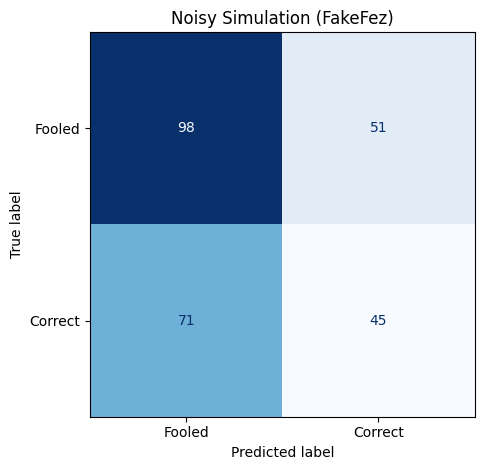

In [40]:
cm = confusion_matrix(Y_test.values, noisy_preds)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('Noisy Simulation (FakeFez)')
plt.tight_layout()
plt.show()

The score and predict functions report slightly different test accuracy values. I believe this is due to label encoding differences. The lower score() result of 0.53 is used throughout the notebook

## 6. Hardware inference: ibm_fez (sample pilot run)

Sample pilot run on 20 test samples using the trained angle encoding & EfficientSU2
circuit to verify the inference pipeline is working before running the full test set.

In [ ]:
my_api_key = ""
my_crn = ""

QiskitRuntimeService.save_account(
    instance=my_crn,
    token=my_api_key,
    overwrite=True,
    channel="ibm_quantum_platform",
)

ibm_service = QiskitRuntimeService()

backend_ibm = ibm_service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(backend_ibm)

print(f"Backend: {backend_ibm.name}")
print(f"Num qubits: {backend_ibm.num_qubits}")
print(f"Pending jobs in queue: {backend_ibm.status().pending_jobs}")


<IBMBackend('ibm_fez')>
Backend: ibm_fez
Num qubits: 156
Pending jobs in queue: 0


### Run inference on ibm_fez - job ran for 23 seconds according to IBM Quantum platform

In [18]:
real_backend = ibm_service.backend("ibm_fez")

# transpile
pm = generate_preset_pass_manager(optimization_level=3, backend=real_backend)
t_fm = pm.run(angle_encode_features(5, 5))
t_ansatz = pm.run(eff_su2(5, 4))

# build VQC directly with real backend
real_sampler = SamplerV2(mode=real_backend)

vqc_hw = VQC(
    sampler=real_sampler,
    feature_map=t_fm,
    ansatz=t_ansatz,
    optimizer=COBYLA(maxiter=1),
    initial_point=weights,
)

# set fit_result without calling fit()
fake_result = OptimizeResult()
fake_result.x = weights
vqc_hw._fit_result = fake_result

####### BURNING CREDITS HERE
# inference call
start = time.time()
# important only 20 samples
predictions_raw = vqc_hw.predict(X_test_q.iloc[:20])
elapsed = time.time() - start
#######

# save raw predictions
np.save('model_outputs/hardware_fez_predictions_raw.npy', predictions_raw)
print(f"Raw predictions saved. Shape: {predictions_raw.shape}")
print(f"Non IBM seconds: {elapsed:.1f}s")

# compute accuracy
true_labels = Y_test.iloc[:20].values
predictions = np.argmax(predictions_raw, axis=1) if predictions_raw.ndim == 2 else predictions_raw
accuracy = accuracy_score(true_labels, predictions)

print(f"\nHardware accuracy (ibm_fez, 20 samples): {accuracy:.4f}")

# save the full result
with open('model_outputs/hardware_fez_results_v3.json', 'w') as f:
    json.dump({
        'backend': 'ibm_fez',
        'n_samples': 20,
        'accuracy': float(accuracy),
        'time_seconds': float(elapsed),
        'predictions': predictions.tolist(),
        'true_labels': true_labels.tolist(),
    }, f, indent=2)
print("Saved")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Raw predictions saved. Shape: (20, 2)
Non IBM seconds: 45.1s

Hardware accuracy (ibm_fez, 20 samples): 0.6000
Saved


## 7. Hardware Inference: ibm_fez (full testset 265 samples)

In [ ]:
# full testset, 265 samples
###### BURNINGING CREDITS HERE
start = time.time()
predictions_raw_full = vqc_hw.predict(X_test_q)
elapsed = time.time() - start
#######


# save raw results
np.save('model_outputs/hardware_fez_predictions_raw_full.npy', predictions_raw_full)
print(f"Full batch raw saved. Shape: {predictions_raw_full.shape}")
print(f"Time: {elapsed:.1f}s")

# test acc
all_preds = np.argmax(predictions_raw_full, axis=1)
all_true = Y_test.values
accuracy_full = (all_preds == all_true).mean()

print(f"\nHardware accuracy (ibm_fez, full 265 samples): {accuracy_full:.4f}")

with open('model_outputs/hardware_fez_full_results.json', 'w') as f:
    json.dump({
        'backend': 'ibm_fez',
        'n_samples': 265,
        'accuracy': float(accuracy_full),
        'wall_clock_seconds': float(elapsed),
    }, f, indent=2)
print("Saved full results")

Full batch raw saved. Shape: (265, 2)
Time: 322.0s

Hardware accuracy (ibm_fez, full 265 samples): 0.5623
Saved full results


## 8. Hardware Results

### Check if model just predicts majority class...

In [41]:
predictions_raw = np.load('model_outputs/hardware_fez_predictions_raw_full.npy')
hw_preds = np.argmax(predictions_raw, axis=1)

print(f"Hardware accuracy: {accuracy_score(Y_test.values, hw_preds):.4f}")
print(f"Hardware macro F1: {f1_score(Y_test.values, hw_preds, average='macro'):.4f}")
print(classification_report(Y_test.values, hw_preds, target_names=['Fooled', 'Correct']))


Hardware accuracy: 0.5623
Hardware macro F1: 0.3599
              precision    recall  f1-score   support

      Fooled       0.56      1.00      0.72       149
     Correct       0.00      0.00      0.00       116

    accuracy                           0.56       265
   macro avg       0.28      0.50      0.36       265
weighted avg       0.32      0.56      0.40       265



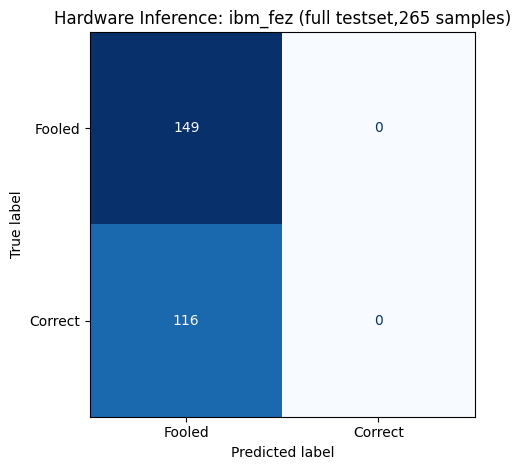

In [42]:
cm = confusion_matrix(Y_test.values, hw_preds)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('Hardware Inference: ibm_fez (full testset,265 samples)')
plt.tight_layout()
plt.show()

Real device collapses to just predicting majority class "Fooled".

## 9. Noiseless Simulation results (full testset 265 samples)

Angle encoding FM & EfficientSU2 ansatz (4 layers).

In [35]:
vqc_noiseless = VQC(
    sampler=StatevectorSampler(),
    feature_map=angle_encode_features(5, 5),
    ansatz=eff_su2(5, 4),
    optimizer=COBYLA(maxiter=1),
)
vqc_noiseless.fit(X_train_q.values[:2], Y_train.values[:2])
vqc_noiseless._fit_result.x = np.load('best_grid_qnn_weights.npy')

noiseless_preds = vqc_noiseless.predict(X_test_q.values)
print(f"Noiseless accuracy: {accuracy_score(Y_test.values, noiseless_preds):.4f}")
print(f"Noiseless macro F1: {f1_score(Y_test.values, noiseless_preds, average='macro'):.4f}")
print(classification_report(Y_test.values, noiseless_preds, target_names=['Fooled', 'Correct']))

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Noiseless accuracy: 0.5472
Noiseless macro F1: 0.5298
              precision    recall  f1-score   support

      Fooled       0.59      0.66      0.62       149
     Correct       0.48      0.41      0.44       116

    accuracy                           0.55       265
   macro avg       0.53      0.53      0.53       265
weighted avg       0.54      0.55      0.54       265



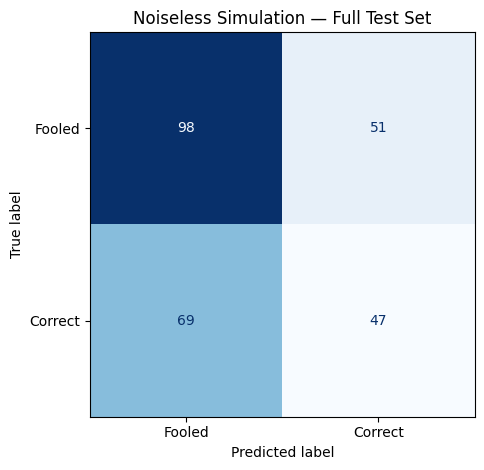

In [36]:
cm = confusion_matrix(Y_test.values, noiseless_preds)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('Noiseless Simulation — Full Test Set')
plt.tight_layout()
plt.show()

## 10. QSVM Hardware Inference (small number of samples)

The trained QSVC kernel parameters are loaded and the model is run on 20 test samples
on ibm_fez.

In [44]:
# instantiate feature map and training params
training_params = ParameterVector('θ', len(qml_features))
fm_rot = QuantumCircuit(len(qml_features))
for i in range(len(qml_features)):
    fm_rot.ry(training_params[i], i)
fm_full = fm_rot.compose(angle_encode_features(len(qml_features), 1))

### Load kernel optimal weights and training subsampled dataset

In [46]:
optimal_params = np.load('qsvm3_optimal_params.npy')
X_train_sub = np.load('model_outputs/qsvc_X_train_sub.npy')
y_train_sub = np.load('model_outputs/qsvc_y_train_sub.npy')

# 20 test samples
X_test_small = X_test_q.values[:20]
y_test_small = Y_test.values[:20]

### Rebuilding quantum kernel and running inference on ibm_fez

In [53]:
basis_gates = real_backend.configuration().basis_gates
print(f"ibm_fez basis gates: {basis_gates}")

ibm_fez basis gates: ['cz', 'id', 'rz', 'sx', 'x']


In [ ]:
real_backend = ibm_service.backend('ibm_fez')
pm = generate_preset_pass_manager(optimization_level=1, backend=real_backend)

# transpile fm_full for the hardware backend
t_fm_full = pm.run(fm_full)

real_sampler = SamplerV2(mode=real_backend)
fidelity_hw = ComputeUncompute(sampler=real_sampler)

qkernel_hw = TrainableFidelityQuantumKernel(
    fidelity=fidelity_hw,
    feature_map=t_fm_full,
    training_parameters=training_params
)
qkernel_hw.assign_training_parameters(optimal_params)

qsvm_hw = QSVC(quantum_kernel=qkernel_hw)
qsvm_hw.fit(X_train_sub, y_train_sub)

# predict on small test sample
X_test_small = X_test_q.values[:20]
y_test_small = Y_test.values[:20]

start = time.time()
hw_qsvm_preds = qsvm_hw.predict(X_test_small)
elapsed = time.time() - start

print(f"Runtime: {elapsed:.1f}s")
print(f"Accuracy: {accuracy_score(y_test_small, hw_qsvm_preds):.4f}")
print(f"Macro f1: {f1_score(y_test_small, hw_qsvm_preds, average='macro'):.4f}")
print(classification_report(y_test_small, hw_qsvm_preds, target_names=['Fooled', 'Correct']))

IBMInputValueError: 'The instruction sxdg on qubits (4,) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled with operator transformations.'

In [ ]:
cm = confusion_matrix(y_test_small, hw_qsvm_preds)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('QSVM inference: ibm_fez (20 samples)')
plt.tight_layout()
plt.show()

### Troubleshooting QSVM HW inference

Hardware inference for the QSVM was attempted but could not be completed due to a
known bug using ComputeUncompute in Qiskit Machine Learning library (https://github.com/Qiskit/qiskit-ibm-runtime/issues/1718). Claude Code helped me troubleshoot this further but I ended up shelving it. 

The noiseless QSVM result (0.622 accuracy, 0.610 macro f1) will be used as the quantum
kernel benchmark in the final comparison instead.

## 11. Simulation vs Hardware Gap

The noiseless simulation (0.547 accuracy,0.53 macro f1) and noisy FakeFez simulation
(0.540 accuracy, 0.520 macro f1) produced similar results. The real hardware result (0.562 accuracy, 0.360 macro f1) collapsed to just predicting the majority class.

The FakeFez noise model partially showed the severe downfall in performance seen on real hardware but did
not fully reproduce it.

## 12. Final Comparison

| Model | Accuracy | Macro F1 |
|---|---|---|
| Majority baseline | 0.562 | 0.360 |
| Logistic Regression | 0.581 | 0.400 |
| KNN | 0.574 | 0.454 |
| Random Forest | 0.570 | 0.186 |
| XGBoost | 0.543 | 0.339 |
| **SVM (rbf)** | **0.615** | **0.549** |
| VQC standalone (ZZ&HardwareEfficient, 50 iter) | 0.556 | n/a |
| VQC best grid (angle&EffSU2, 4L, 50 iter) |**0.630** | n/a |
| VQC retrained (angle&EffSU2, 4L, 150 iter) | 0.555 | 0.523 |
| VQC custom ansatz (angle&skill_gap, 120 iter) | 0.555 | 0.516 |
| VQC alternative features (angle&EffSU2, 150 iter) | 0.517 | 0.522 |
| **QSVM COBYLA** (100 samples, 50 iter) | **0.622** | **0.610** |
| VQC noisy simulation (FakeFez) | 0.540 | 0.520 |
| VQC hardware (ibm_fez) | 0.562 | 0.360 |

No noiseless VQC model reliably beat the performance of the classical SVM (rbf). The QSVM with COBYLA
 was the strongest quantum result overall at 0.622 accuracy and 0.610 macro f1, matching and slightly exceeding the classical SVM (though only trained on 100 of 500 samples).

Hardware inference on ibm_fez collapsed to pure majority class prediction (0.562 accuracy,
0.360 macro f1). The same circuit predicted both Correct/Fooled classes in noiseless simulation. This confirms that physical device noise rather than circuit design is the limiting factor for this performance drop. This comparison aligns with the discussion in "Quantum machine learning" by Biamonte et al., 2017 where near-term quantum hardware is extremely error prone and is the dominant challenge in the NISQ-era of QML.

QSVM hardware inference failed to run due to a bug I was unable to solve. The kernel failed on ibm_fez due to a known incompatibility between ComputeUncompute and the hardware sampler.

## 13. Final remarks / conclusions / future work

This project compared classical and quantum machine learning approaches for predicting
panel accuracy on the WILTY comedy dataset!

**Main findings/conclusions:**
- The classical SVM (RBF) was the strongest classical model at 0.615 accuracy and 0.549 f1.
- The best noiseless VQC (angle & EffSU2, 4 layers) achieved 0.547 accuracy and 0.530 f1. This was worse than the classical model but above the majority baseline. The circuit did learn a real yet weak signal from the encoded features.
- The QSVM with COBYLA (100 samples) achieved 0.622 accuracy and 0.610 f1 which more or less equalled the classical SVM (even though the training dataset was subsampled to 100 samples).
- Hardware inference on ibm_fez collapsed to just predicting the majority class prediction (0.562 accuracy and 0.36 macro f1).


**Limitations:**
- The dataset is quite small (765 rows) and the signal is weak.
- Custom features built involved biases and assumptions about what I thought would be key to the panel achieving high correct judgement. A different feature eng approach would very likely yield much different results.
- The grid search was limited to 50 COBYLA iterations per trial and involved pruning in order to have it successful run overnight.
- Hardware inference used model weights trained in purely noiseless simulation. No noisy
  retraining was run.
- Failed to run inference of QSVM model on ibm_fez.

**Future work / Extensions:**
- Noisy training using a FakeFez backend during optimisation. Get QSVM inference running on real hardware.
- Could have further trained the QSVM using full training dataset (no subsampling).
- Possibly other data encoding strategies such as data reuploading could have been used.
- Data scaling by $\pi$ could have improved the angle encoding.
- Other feature maps, ansätze, optimisers may be out there that could be further explored if I didn't get stuck in the weeds with the feature engineering.
- A larger, richer dataset..ideally including statement text or sentiment features!
- Maybe just standard NLP would be more successful at this task..! 

Overall it was a good challenge and I definitely enjoyed diving into the weeds of building different types of classical and quantum models. I hope it came across as somewhat of an interesting project, despite the mixed bag of model performances!

-EOF-